<a href="https://colab.research.google.com/github/Ramesh134M/AD23633_Generative_AI_Lab/blob/main/Exp_6B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets pandas matplotlib openai -q

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import pipeline


In [3]:
# Load dataset
dataset = load_dataset("openai/gsm8k", "main")
# Take only a small subset for lab
samples = dataset["test"].select(range(5)) # change 5 to 10 if needed
print("Number of questions selected:", len(samples))
print("\nFirst sample:")
print(samples[0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Number of questions selected: 5

First sample:
{'question': "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?", 'answer': 'Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.\nShe makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.\n#### 18'}


In [5]:
generator = pipeline(
 "text-generation",
 model="google/flan-t5-small"
)
print("Model loaded successfully.")

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'FalconMambaForCausa

Model loaded successfully.


In [6]:
def zero_shot_prompt(question):
 return f"""
Solve the following math problem.
Give only the final answer.
Question: {question}
"""
def few_shot_prompt(question):
 return f"""
Solve the following math problems.
Example 1:
Question: Ravi has 3 apples and buys 2 more. How many apples does he have?
Answer: 5
Example 2:
Question: There are 4 pencils in one box. If there are 3 boxes, how many pencils are
there?
Answer: 12
Now solve this:
Question: {question}
Answer:
"""
def cot_prompt(question):
 return f"""
Solve the following math problem step by step.
Then write the final answer clearly at the end.
Question: {question}
"""


In [13]:
def get_response(prompt):
 output = generator(
 prompt,
 max_new_tokens=128, # Changed from max_length to max_new_tokens for clarity and to resolve warnings
 do_sample=False
 )
 return output[0]["generated_text"]

In [14]:
def extract_number(text):
  numbers = re.findall(r'-?\d+\.?\d*', text.replace(",", ""))
  if len(numbers) > 0:
    return numbers[-1]
  return None

In [15]:
results = []
for i, sample in enumerate(samples):
 question = sample["question"]
 true_answer_text = sample["answer"]
 # Extract the final numeric answer from dataset answer text
 true_answer = extract_number(true_answer_text)
 # Zero-shot
 z_prompt = zero_shot_prompt(question)
 z_response = get_response(z_prompt)
 z_pred = extract_number(z_response)
 results.append({
 "id": i,
 "question": question,
 "prompt_type": "Zero-shot",
 "model_response": z_response,
 "true_answer": true_answer,
 "predicted_answer": z_pred
 })
 # Chain-of-Thought
 c_prompt = cot_prompt(question)
 c_response = get_response(c_prompt)
 c_pred = extract_number(c_response)
 results.append({
     "id": i,
 "question": question,
 "prompt_type": "Chain-of-Thought",
 "model_response": c_response,
 "true_answer": true_answer,
 "predicted_answer": c_pred
 })
print("Experiment completed.")

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gen

Experiment completed.


In [16]:
df = pd.DataFrame(results)
df.head(10)


,id,question,prompt_type,model_response,true_answer,predicted_answer
0,0,Janet’s ducks lay 16 eggs per day. She eats th...,Zero-shot,\nSolve the following math problem.\nGive only...,18,2
1,0,Janet’s ducks lay 16 eggs per day. She eats th...,Chain-of-Thought,\nSolve the following math problem step by ste...,18,2
2,1,A robe takes 2 bolts of blue fiber and half th...,Zero-shot,\nSolve the following math problem.\nGive only...,3,2
3,1,A robe takes 2 bolts of blue fiber and half th...,Chain-of-Thought,\nSolve the following math problem step by ste...,3,2
4,2,Josh decides to try flipping a house. He buys...,Zero-shot,\nSolve the following math problem.\nGive only...,70000,150
5,2,Josh decides to try flipping a house. He buys...,Chain-of-Thought,\nSolve the following math problem step by ste...,70000,150
6,3,James decides to run 3 sprints 3 times a week....,Zero-shot,\nSolve the following math problem.\nGive only...,540,60
7,3,James decides to run 3 sprints 3 times a week....,Chain-of-Thought,\nSolve the following math problem step by ste...,540,240
8,4,"Every day, Wendi feeds each of her chickens th...",Zero-shot,\nSolve the following math problem.\nGive only...,20,20
9,4,"Every day, Wendi feeds each of her chickens th...",Chain-of-Thought,\nSolve the following math problem step by ste...,20,20


In [17]:
df["is_correct"] = df["true_answer"] == df["predicted_answer"]
df[["id", "prompt_type", "true_answer", "predicted_answer", "is_correct"]]

,id,prompt_type,true_answer,predicted_answer,is_correct
0,0,Zero-shot,18,2,False
1,0,Chain-of-Thought,18,2,False
2,1,Zero-shot,3,2,False
3,1,Chain-of-Thought,3,2,False
4,2,Zero-shot,70000,150,False
5,2,Chain-of-Thought,70000,150,False
6,3,Zero-shot,540,60,False
7,3,Chain-of-Thought,540,240,False
8,4,Zero-shot,20,20,True
9,4,Chain-of-Thought,20,20,True


In [18]:
accuracy_table = df.groupby("prompt_type")["is_correct"].mean() * 100
accuracy_table = accuracy_table.reset_index()
accuracy_table.columns = ["Prompt Type", "Accuracy (%)"]
print(accuracy_table)


        Prompt Type  Accuracy (%)
0  Chain-of-Thought          20.0
1         Zero-shot          20.0


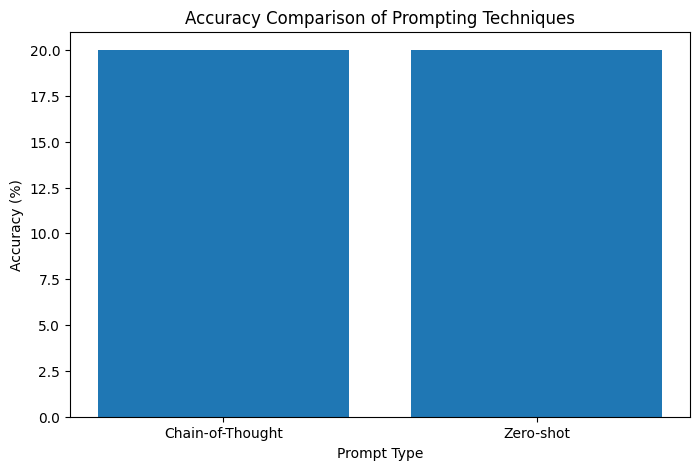

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(accuracy_table["Prompt Type"], accuracy_table["Accuracy (%)"])
plt.xlabel("Prompt Type")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Prompting Techniques")
plt.show()
